In [9]:
#Import all necessary packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

import geopandas as gpd

In [ ]:
#Kansas Risk Calculations

In [10]:
#Loading in kansas data
KS_nri = pd.read_csv("NRI_Table_Kansas.csv")
KS_svi = pd.read_csv("SVI_Kansas.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

print(KS_nri)
print(nri_dictionary)
print(KS_svi)

      OID_        NRI_ID   STATE STATEABBRV  STATEFIPS     COUNTY COUNTYTYPE  \
0    30746  T20001952600  Kansas         KS         20      Allen     County   
1    30747  T20001952700  Kansas         KS         20      Allen     County   
2    30748  T20001952800  Kansas         KS         20      Allen     County   
3    30749  T20001952900  Kansas         KS         20      Allen     County   
4    30750  T20001953000  Kansas         KS         20      Allen     County   
..     ...           ...     ...        ...        ...        ...        ...   
824  31570  T20209980000  Kansas         KS         20  Wyandotte     County   
825  31571  T20209980500  Kansas         KS         20  Wyandotte     County   
826  31572  T20209980900  Kansas         KS         20  Wyandotte     County   
827  31573  T20209981200  Kansas         KS         20  Wyandotte     County   
828  31574  T20209981500  Kansas         KS         20  Wyandotte     County   

     COUNTYFIPS  STCOFIPS   TRACT  ... 

In [11]:
#Joining the NRI and SVI Data sets for kansas
KS_nri['STCNTY'] = KS_nri['STCOFIPS']
KS_nri.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

In [12]:
#Joining the NRI and SVI Data sets for kansas and get rid of empty or repeating columns
complete_Kansas = pd.merge(KS_nri, KS_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_Kansas.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [13]:
#Filling Missing data points with median values
Kansas_data = complete_Kansas.copy() 
KS_filled_median = Kansas_data.fillna(Kansas_data.median(numeric_only = True))

print(KS_filled_median)

        OID_        NRI_ID   STATE STATEABBRV  STATEFIPS     COUNTY  \
0      30746  T20001952600  Kansas         KS         20      Allen   
1      30746  T20001952600  Kansas         KS         20      Allen   
2      30746  T20001952600  Kansas         KS         20      Allen   
3      30746  T20001952600  Kansas         KS         20      Allen   
4      30746  T20001952600  Kansas         KS         20      Allen   
...      ...           ...     ...        ...        ...        ...   
52234  31574  T20209981500  Kansas         KS         20  Wyandotte   
52235  31574  T20209981500  Kansas         KS         20  Wyandotte   
52236  31574  T20209981500  Kansas         KS         20  Wyandotte   
52237  31574  T20209981500  Kansas         KS         20  Wyandotte   
52238  31574  T20209981500  Kansas         KS         20  Wyandotte   

      COUNTYTYPE  COUNTYFIPS  STCOFIPS   TRACT  ...  EP_ASIAN  MP_ASIAN  \
0         County           1     20001  952600  ...       0.7       1.0 

In [14]:
#Calculating Kansas risk for wildfires using NRI definition
complete_Kansas['Wildfire_building_risk'] = complete_Kansas['WFIR_AFREQ']*complete_Kansas['WFIR_EXPB']
complete_Kansas['Wildfire_Population_Risk'] = complete_Kansas['WFIR_AFREQ']*complete_Kansas['WFIR_EXPP']
complete_Kansas['Wildfire_Population_Equiv'] = complete_Kansas['WFIR_AFREQ']*complete_Kansas['WFIR_EXPPE']

complete_Kansas['Tornado_building_risk'] = complete_Kansas['TRND_AFREQ']*complete_Kansas['TRND_EXPB']
complete_Kansas['Tornado_Population_Risk'] = complete_Kansas['TRND_AFREQ']*complete_Kansas['TRND_EXPP']
complete_Kansas['Tornado_Population_Equiv'] = complete_Kansas['TRND_AFREQ']*complete_Kansas['TRND_EXPPE']

print(complete_Kansas)


        OID_        NRI_ID   STATE STATEABBRV  STATEFIPS     COUNTY  \
0      30746  T20001952600  Kansas         KS         20      Allen   
1      30746  T20001952600  Kansas         KS         20      Allen   
2      30746  T20001952600  Kansas         KS         20      Allen   
3      30746  T20001952600  Kansas         KS         20      Allen   
4      30746  T20001952600  Kansas         KS         20      Allen   
...      ...           ...     ...        ...        ...        ...   
52234  31574  T20209981500  Kansas         KS         20  Wyandotte   
52235  31574  T20209981500  Kansas         KS         20  Wyandotte   
52236  31574  T20209981500  Kansas         KS         20  Wyandotte   
52237  31574  T20209981500  Kansas         KS         20  Wyandotte   
52238  31574  T20209981500  Kansas         KS         20  Wyandotte   

      COUNTYTYPE  COUNTYFIPS  STCOFIPS   TRACT  ...  EP_TWOMORE  MP_TWOMORE  \
0         County           1     20001  952600  ...         3.7     

In [15]:
#Grouping data by county
grouped_data = complete_Kansas.groupby('COUNTY',as_index=False)

##Getting the mean values for counties by building risk
grouped_data = complete_Kansas.groupby('COUNTY').agg(mean_wfir=('Wildfire_building_risk', 'mean'), 
                                                   mean_trnd=('Tornado_building_risk', 'mean'))

print(grouped_data)

               mean_wfir     mean_trnd
COUNTY                                
Allen       2.321139e+04  3.135344e+07
Anderson    7.643994e+04  1.509067e+08
Atchison    2.315330e+05  1.202345e+08
Barber      3.501386e+06  5.863098e+08
Barton      9.630845e+04  1.820594e+08
...                  ...           ...
Washington  6.179458e+05  6.715340e+08
Wichita     3.808852e+04  6.271310e+08
Wilson      1.035071e+05  5.388697e+07
Woodson     3.031410e+05  1.181735e+08
Wyandotte   3.502848e+03  1.529005e+06

[105 rows x 2 columns]


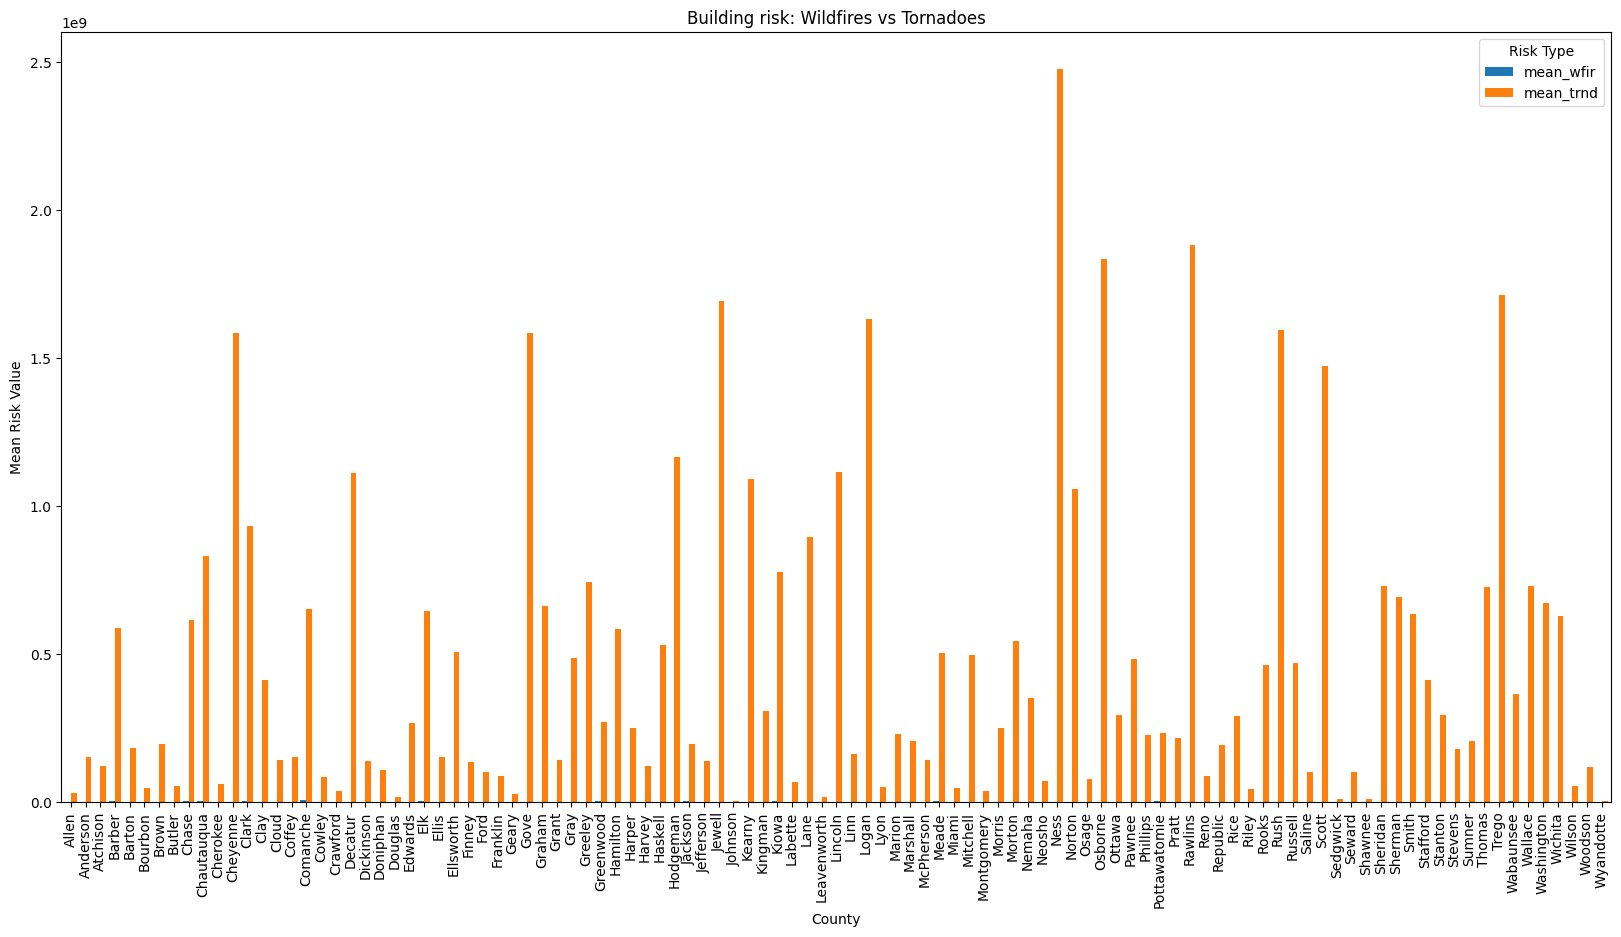

In [16]:
#Comparing building risk mean values across Kansas counties
grouped_data.plot(kind='bar', figsize=(20, 10), width=0.8)

plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Building risk: Wildfires vs Tornadoes')
plt.xticks(rotation=90)

plt.legend(title="Risk Type")  
plt.show()

In [68]:
#Calculating risk with my our own Definition for Tornadoes
complete_Kansas["RISK_INDEX_TRND"] = complete_Kansas["TRND_AFREQ"] * (complete_Kansas["TRND_EALT"] / complete_Kansas["AREA"]) #Area in Square Miles
print(complete_Kansas["RISK_INDEX_TRND"])


0         80.497375
1         80.497375
2         80.497375
3         80.497375
4         80.497375
            ...    
52234    157.480044
52235    157.480044
52236    157.480044
52237    157.480044
52238    157.480044
Name: RISK_INDEX_TRND, Length: 52239, dtype: float64


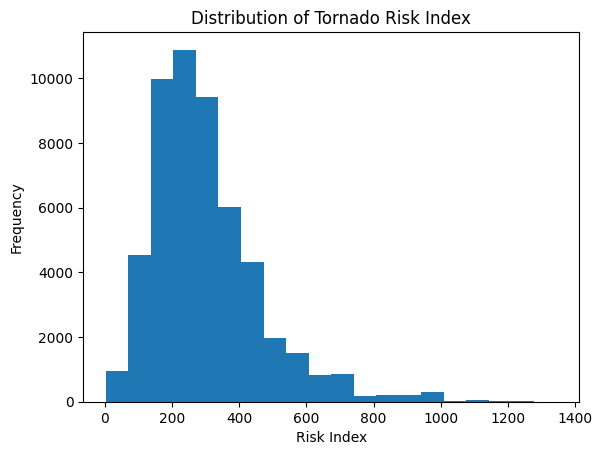

In [69]:
#Histogram plot of our method to show risk
plt.figure()
plt.hist(complete_Kansas["RISK_INDEX_TRND"], bins=20)
plt.title("Distribution of Tornado Risk Index")
plt.xlabel("Risk Index")
plt.ylabel("Frequency")
plt.show()

In [65]:
#Calculating risk with my our own Definition for Wildfires
complete_Kansas["RISK_INDEX_WFIR"] = complete_Kansas["WFIR_AFREQ"] * (complete_Kansas["WFIR_EALT"] / complete_Kansas["AREA"]) #Area in Square Miles
print(complete_Kansas["RISK_INDEX_WFIR"])

0        0.004836
1        0.004836
2        0.004836
3        0.004836
4        0.004836
           ...   
52234    0.000690
52235    0.000690
52236    0.000690
52237    0.000690
52238    0.000690
Name: RISK_INDEX_WFIR, Length: 52239, dtype: float64


In [66]:
#Box Plot showing Kansas wildfire risk

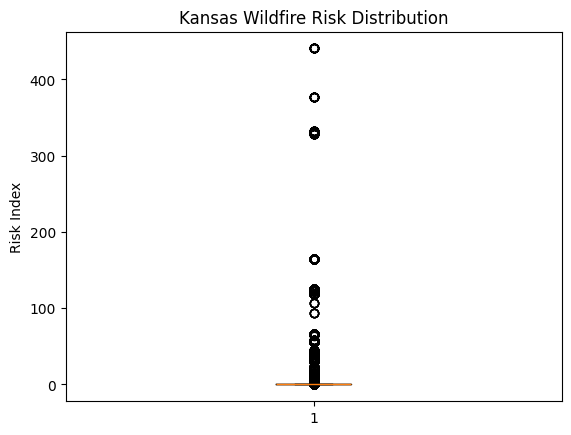

In [67]:
plt.figure
plt.boxplot(complete_Kansas["RISK_INDEX_WFIR"].dropna(), vert = True)
plt.title("Kansas Wildfire Risk Distribution")
plt.ylabel("Risk Index")
plt.show()

In [ ]:
#Wyoming Risk Calculations

In [50]:
#Import Wyoming data
WY_nri = pd.read_csv("NRI_Table_Wyoming.csv")
WY_svi = pd.read_csv("SVI_Wyoming.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

print(WY_nri)
print(nri_dictionary)
print(WY_svi)

      OID_        NRI_ID    STATE STATEABBRV  STATEFIPS    COUNTY COUNTYTYPE  \
0    83934  T56001962700  Wyoming         WY         56    Albany     County   
1    83935  T56001962800  Wyoming         WY         56    Albany     County   
2    83936  T56001962900  Wyoming         WY         56    Albany     County   
3    83937  T56001963000  Wyoming         WY         56    Albany     County   
4    83938  T56001963101  Wyoming         WY         56    Albany     County   
..     ...           ...      ...        ...        ...       ...        ...   
155  84089  T56043000200  Wyoming         WY         56  Washakie     County   
156  84090  T56043000301  Wyoming         WY         56  Washakie     County   
157  84091  T56043000302  Wyoming         WY         56  Washakie     County   
158  84092  T56045951100  Wyoming         WY         56    Weston     County   
159  84093  T56045951300  Wyoming         WY         56    Weston     County   

     COUNTYFIPS  STCOFIPS   TRACT  ... 

In [51]:
#Joining the NRI and SVI Data sets for kansas
WY_nri['STCNTY'] = WY_nri['STCOFIPS']

WY_nri['STCNTY'] = WY_nri['STCNTY'].astype(str).str.strip()
WY_svi['STCNTY'] = WY_svi['STCNTY'].astype(str).str.strip()

WY_nri.columns

Index([' OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

In [52]:
#Joining the NRI and SVI Data sets for Wyoming and get rid of empty or repeating columns
complete_Wyoming = pd.merge(WY_nri, WY_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_Wyoming.columns

Index([' OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [53]:
#Finding empty or Missing values in the data set
Wyoming_data = pd.read_csv("SVI_Wyoming.csv")
Wyoming_data.isna()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
156,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
157,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
158,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [54]:
#Filling Missing data points with median values
WY_filled_median = Wyoming_data.fillna(Wyoming_data.median(numeric_only = True))

print(WY_filled_median)

     ST    STATE ST_ABBR  STCNTY           COUNTY         FIPS  \
0    56  Wyoming      WY   56001    Albany County  56001962700   
1    56  Wyoming      WY   56001    Albany County  56001962800   
2    56  Wyoming      WY   56001    Albany County  56001962900   
3    56  Wyoming      WY   56001    Albany County  56001963000   
4    56  Wyoming      WY   56001    Albany County  56001963101   
..   ..      ...     ...     ...              ...          ...   
155  56  Wyoming      WY   56043  Washakie County  56043000200   
156  56  Wyoming      WY   56043  Washakie County  56043000301   
157  56  Wyoming      WY   56043  Washakie County  56043000302   
158  56  Wyoming      WY   56045    Weston County  56045951100   
159  56  Wyoming      WY   56045    Weston County  56045951300   

                                         LOCATION    AREA_SQMI  E_TOTPOP  \
0       Census Tract 9627; Albany County; Wyoming   243.035990      2997   
1       Census Tract 9628; Albany County; Wyoming     3

In [55]:
complete_Wyoming['Wildfire_building_risk'] = complete_Wyoming['WFIR_AFREQ']*complete_Wyoming['WFIR_EXPB']
complete_Wyoming['Wildfire_Population_Risk'] = complete_Wyoming['WFIR_AFREQ']*complete_Wyoming['WFIR_EXPP']
complete_Wyoming['Wildfire_Population_Equiv'] = complete_Wyoming['WFIR_AFREQ']*complete_Wyoming['WFIR_EXPPE']

complete_Wyoming['Tornado_building_risk'] = complete_Wyoming['TRND_AFREQ']*complete_Wyoming['TRND_EXPB']
complete_Wyoming['Tornado_Population_Risk'] = complete_Wyoming['TRND_AFREQ']*complete_Wyoming['TRND_EXPP']
complete_Wyoming['Tornado_Population_Equiv'] = complete_Wyoming['TRND_AFREQ']*complete_Wyoming['TRND_EXPPE']

print(complete_Wyoming)


       OID_        NRI_ID    STATE STATEABBRV  STATEFIPS    COUNTY COUNTYTYPE  \
0     83934  T56001962700  Wyoming         WY         56    Albany     County   
1     83934  T56001962700  Wyoming         WY         56    Albany     County   
2     83934  T56001962700  Wyoming         WY         56    Albany     County   
3     83934  T56001962700  Wyoming         WY         56    Albany     County   
4     83934  T56001962700  Wyoming         WY         56    Albany     County   
...     ...           ...      ...        ...        ...       ...        ...   
1981  84091  T56043000302  Wyoming         WY         56  Washakie     County   
1982  84092  T56045951100  Wyoming         WY         56    Weston     County   
1983  84092  T56045951100  Wyoming         WY         56    Weston     County   
1984  84093  T56045951300  Wyoming         WY         56    Weston     County   
1985  84093  T56045951300  Wyoming         WY         56    Weston     County   

      COUNTYFIPS  STCOFIPS 

In [56]:
#Grouping data by county
grouped_data = complete_Wyoming.groupby('COUNTY',as_index=False)

##Getting the mean values for counties by building risk
grouped_data = complete_Wyoming.groupby('COUNTY').agg(mean_wfir=('Wildfire_building_risk', 'mean'), 
                                                   mean_trnd=('Tornado_building_risk', 'mean'))

print(grouped_data)

                mean_wfir     mean_trnd
COUNTY                                 
Albany       2.245210e+05  9.425334e+07
Big Horn     8.846084e+04  8.796209e+07
Campbell     1.092782e+06  7.587788e+07
Carbon       3.418666e+05  5.696512e+07
Converse     1.255492e+06  2.908586e+08
Crook        1.269934e+06  3.911770e+08
Fremont      4.899720e+05  2.225599e+07
Goshen       1.810529e+05  2.432235e+08
Hot Springs  1.564216e+05  4.817654e+07
Johnson      1.107369e+06  1.870740e+08
Laramie      2.193591e+05  8.924178e+07
Lincoln      4.641246e+05  4.119782e+07
Natrona      4.500303e+05  3.368528e+07
Niobrara     9.827488e+05  5.079636e+08
Park         2.199631e+05  4.239046e+07
Platte       7.224208e+05  1.571858e+08
Sheridan     1.333388e+06  3.716123e+07
Sublette     1.039497e+06  6.716944e+07
Sweetwater   4.175699e+04  3.245136e+07
Teton        1.035346e+06  1.934314e+07
Uinta        4.324610e+05  1.307094e+07
Washakie     1.098253e+05  5.782052e+07
Weston       1.036320e+06  2.883519e+08


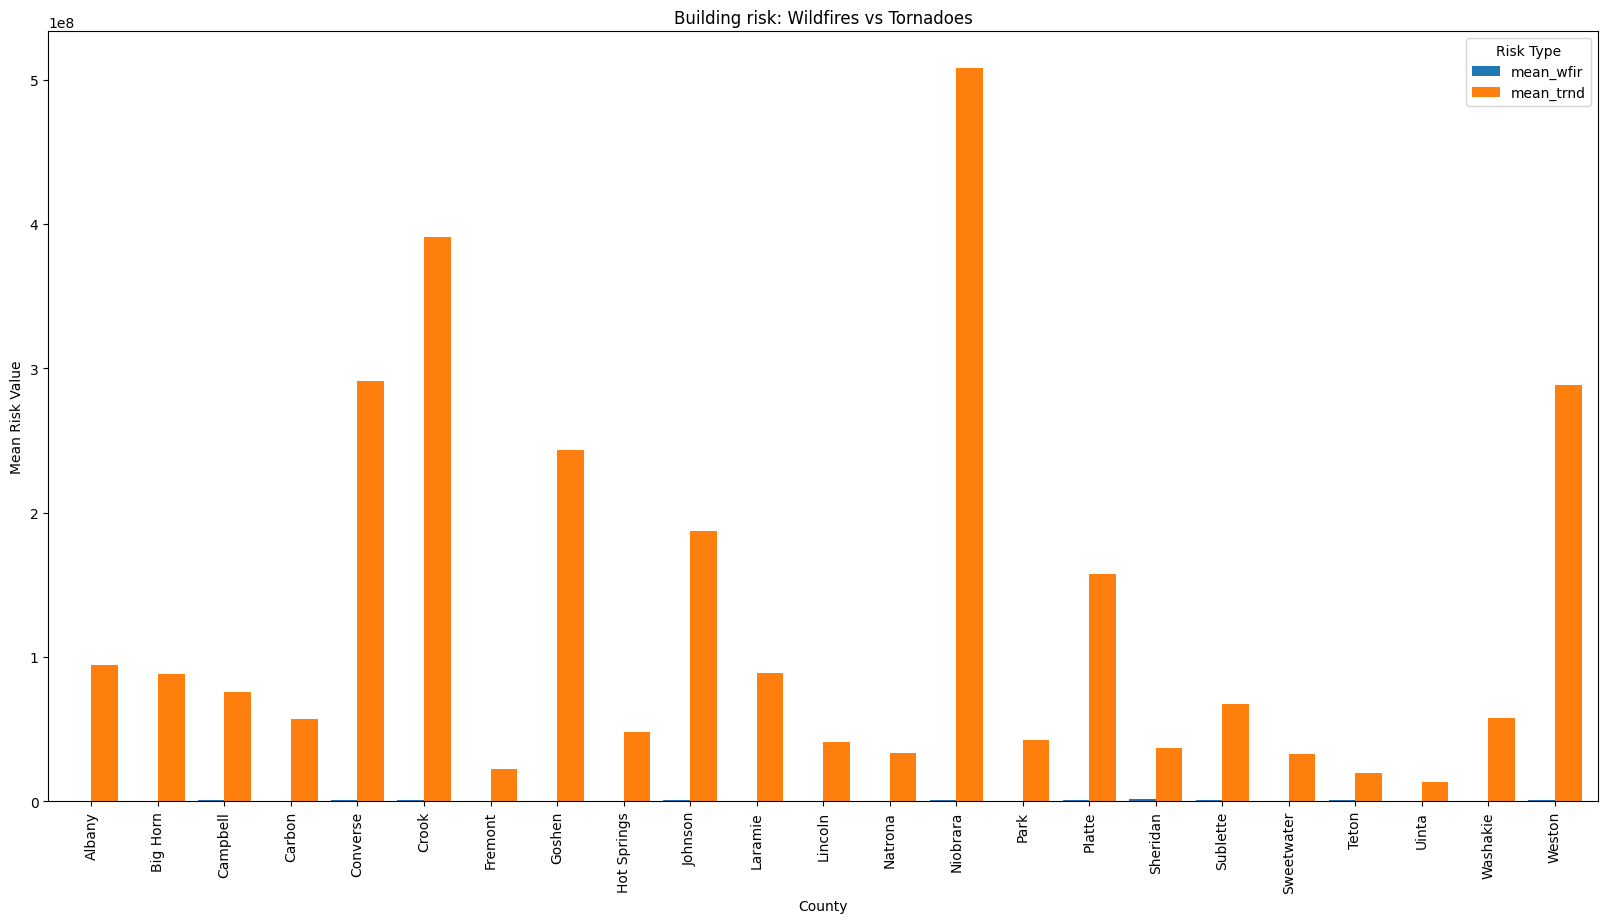

In [57]:
#Comparing building risk mean values across Wyoming counties
grouped_data.plot(kind='bar', figsize=(20, 10), width=0.8)

plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Building risk: Wildfires vs Tornadoes')
plt.xticks(rotation=90)

plt.legend(title="Risk Type")  
plt.show()

In [63]:
#Calculating risk with my our own Definition for Tornadoes
complete_Wyoming["RISK_INDEX_TRND"] = complete_Wyoming["TRND_AFREQ"] * (complete_Wyoming["TRND_EALT"] / complete_Wyoming["AREA"]) #Area in Square Miles
print(complete_Wyoming["RISK_INDEX_TRND"])

0       16.372780
1       16.372780
2       16.372780
3       16.372780
4       16.372780
          ...    
1981     2.211726
1982    34.327349
1983    34.327349
1984    43.998051
1985    43.998051
Name: RISK_INDEX_TRND, Length: 1986, dtype: float64


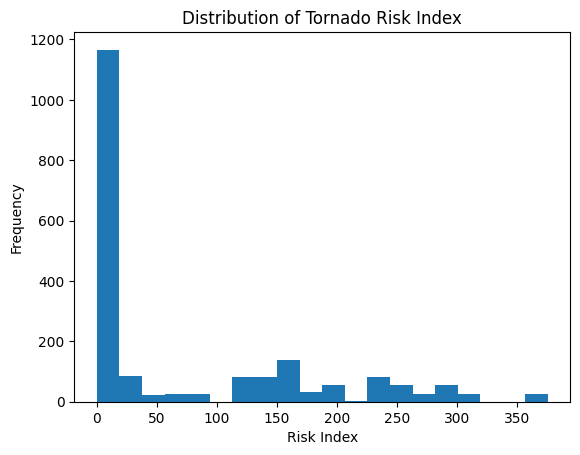

In [64]:
#Histogram plot of our method to show risk
plt.figure()
plt.hist(complete_Wyoming["RISK_INDEX_TRND"], bins=20)
plt.title("Distribution of Tornado Risk Index")
plt.xlabel("Risk Index")
plt.ylabel("Frequency")
plt.show()

In [62]:
#Calculating risk with my our own Definition for Wildfires
complete_Wyoming["RISK_INDEX_WFIR"] = complete_Wyoming["WFIR_AFREQ"] * (complete_Wyoming["WFIR_EALT"] / complete_Wyoming["AREA"]) #Area in Square Miles
print(complete_Wyoming["RISK_INDEX_WFIR"])

0        0.942509
1        0.942509
2        0.942509
3        0.942509
4        0.942509
          ...    
1981     0.060853
1982     0.673424
1983     0.673424
1984    20.790292
1985    20.790292
Name: RISK_INDEX_WFIR, Length: 1986, dtype: float64


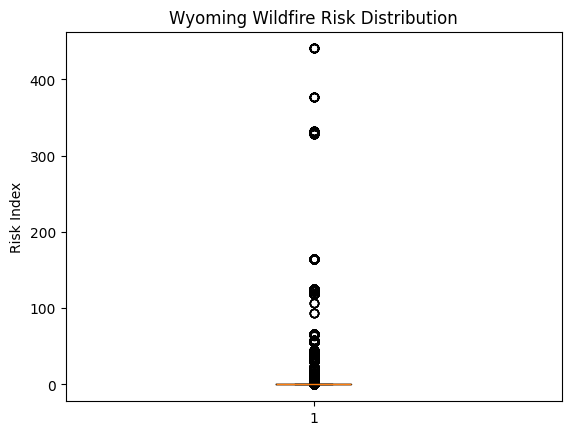

In [70]:
plt.figure
plt.boxplot(complete_Kansas["RISK_INDEX_WFIR"].dropna(), vert = True)
plt.title("Wyoming Wildfire Risk Distribution")
plt.ylabel("Risk Index")
plt.show()

In [ ]:
#Geopandas Map

In [3]:
#Importing census data for GeoPandas map
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

tracts.head()

tracts.crs

tracts.geometry.head

<bound method NDFrame.head of 0        POLYGON ((-9626784.493 3827718.774, -9626802.4...
1        POLYGON ((-9625497.973 3827700.43, -9625504.76...
2        POLYGON ((-9623646.617 3823891.992, -9623666.3...
3        POLYGON ((-9622012.001 3826514.039, -9622007.2...
4        POLYGON ((-9619304.709 3823820.353, -9619304.3...
                               ...                        
85149    MULTIPOLYGON (((-7229559.263 2076162.994, -722...
85150    MULTIPOLYGON (((-7223804.932 2070298.376, -722...
85151    MULTIPOLYGON (((-7228705.998 2076914.822, -722...
85152    POLYGON ((-7225164.255 2077854.794, -7225225.1...
85153    MULTIPOLYGON (((-7226976.872 2076635.478, -722...
Name: geometry, Length: 85154, dtype: geometry>

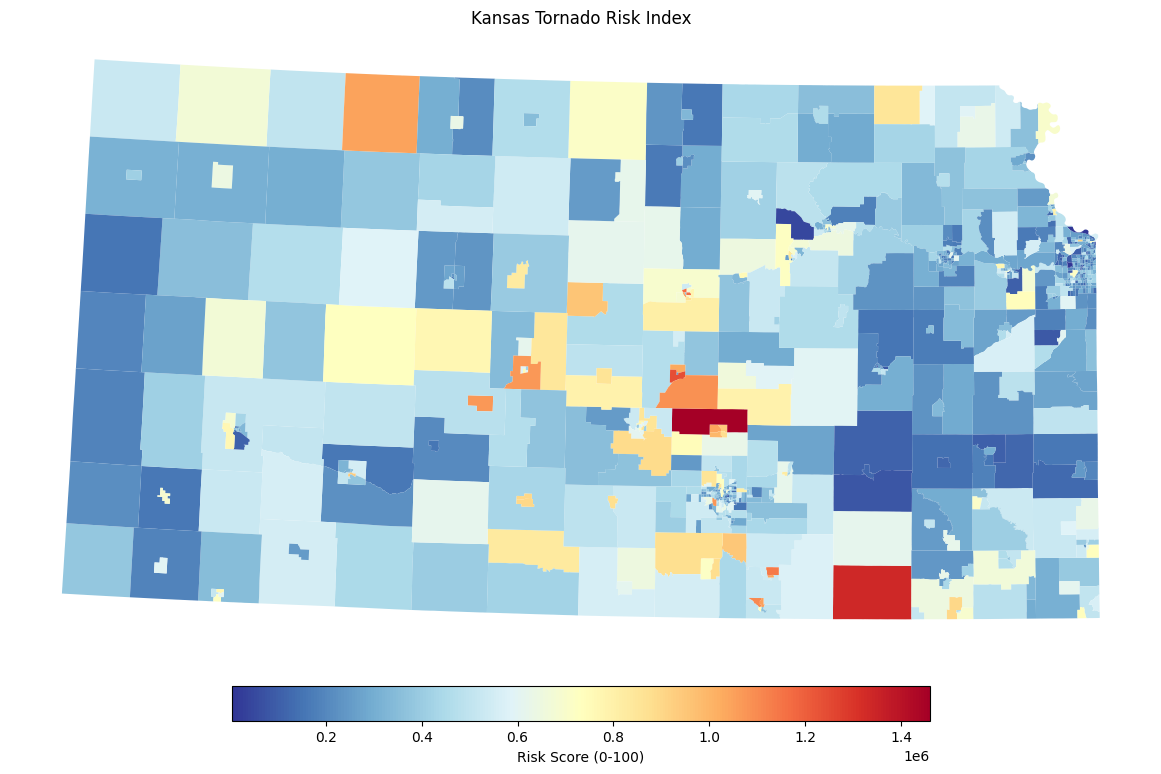

In [34]:
#Creating Map of Tornado risk based on Index values in kansas
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

state_map = tracts[tracts["STATE"] == "Kansas"].copy()
state_map = state_map.replace(-9999, np.nan)


state_map = state_map.to_crs("ESRI:102003")

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

state_map.plot(
    column="TRND_RISKV", 
    cmap="RdYlBu_r",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6,"pad":0.05},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Kansas Tornado Risk Index")
ax.set_axis_off()
plt.show()